# Checking Missing Values

In [3]:
import pandas as pd

# load data
df = pd.read_csv('/mtsamples.csv')

# dataset shape and columns
print("Shape:", df.shape)
print("\nColumns:", df.columns.tolist())
print("\nInfo:")
df.info()

# missing values
missing = df.isnull().sum()
missing_pct = (df.isnull().sum() / len(df)) * 100
missing_df = pd.DataFrame({'Missing Count': missing, 'Percentage': missing_pct})
print("\nMissing Values:\n", missing_df)

Shape: (4999, 6)

Columns: ['Unnamed: 0', 'description', 'medical_specialty', 'sample_name', 'transcription', 'keywords']

Info:
<class 'pandas.core.frame.DataFrame'>
RangeIndex: 4999 entries, 0 to 4998
Data columns (total 6 columns):
 #   Column             Non-Null Count  Dtype 
---  ------             --------------  ----- 
 0   Unnamed: 0         4999 non-null   int64 
 1   description        4999 non-null   object
 2   medical_specialty  4999 non-null   object
 3   sample_name        4999 non-null   object
 4   transcription      4966 non-null   object
 5   keywords           3931 non-null   object
dtypes: int64(1), object(5)
memory usage: 234.5+ KB

Missing Values:
                    Missing Count  Percentage
Unnamed: 0                     0    0.000000
description                    0    0.000000
medical_specialty              0    0.000000
sample_name                    0    0.000000
transcription                 33    0.660132
keywords                    1068   21.364273


0.66% missing for transcription - drop those rows as the agent won't be able to explain a note that DNE. Can fill missing values for keywords (21.36% missing) with "None."

# Distribution of Medical Specialities

/tmp/ipykernel_1158/3532810880.py:7: FutureWarning: 

Passing `palette` without assigning `hue` is deprecated and will be removed in v0.14.0. Assign the `y` variable to `hue` and set `legend=False` for the same effect.

  sns.barplot(x=specialty_counts.values[:15], y=specialty_counts.index[:15], palette='bright')


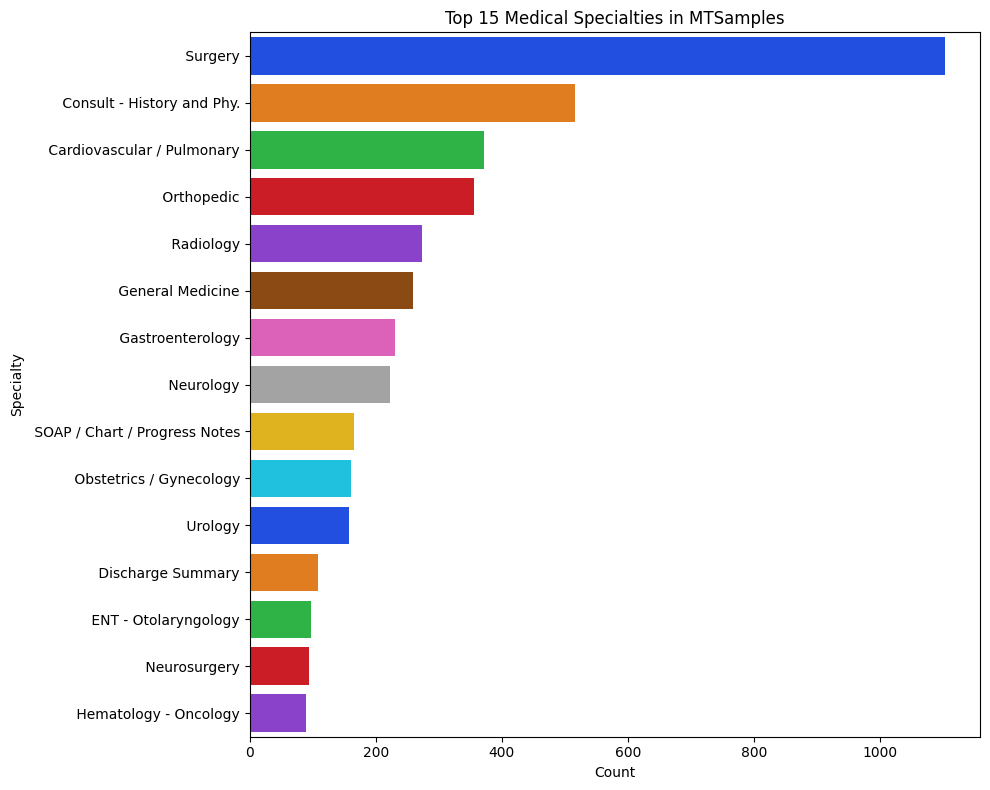

Number of unique specialties: 40


In [5]:
import matplotlib.pyplot as plt
import seaborn as sns

# distribution of medical specialties
plt.figure(figsize=(10, 8))
specialty_counts = df['medical_specialty'].value_counts()
sns.barplot(x=specialty_counts.values[:15], y=specialty_counts.index[:15], palette='bright')
plt.title('Top 15 Medical Specialties in MTSamples')
plt.xlabel('Count')
plt.ylabel('Specialty')
plt.tight_layout()
plt.show()

print("Number of unique specialties:", df['medical_specialty'].nunique())

The dataset is dominated by specialities such as Surgery, Consult - History & Phy, and Cardiovascular. Since Hematology - Oncology, Neurosurgery, and ENT - Otolaryngology have very few examples and are rare specialities, we should try to pay more attention to them during evaluation.

As medical records and reports concerning cancer and rare cases with neurosurgery are important, we should take more care to them - maybe having to generate synthetic data?

# Transcription Lengths

        char_length   word_count
count   4999.000000  4999.000000
mean    3032.165033   462.376275
std     2002.802464   317.585206
min        0.000000     0.000000
25%     1590.500000   239.000000
50%     2659.000000   397.000000
75%     3995.000000   614.000000
max    18425.000000  3029.000000


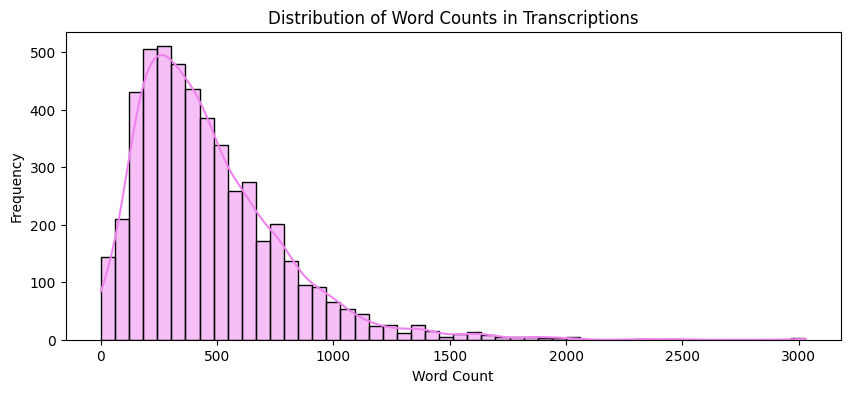

In [7]:
# character and word lengths for transcriptions
df['char_length'] = df['transcription'].fillna('').apply(len)
df['word_count'] = df['transcription'].fillna('').apply(lambda x: len(x.split()))

# summary statistics for length
print(df[['char_length', 'word_count']].describe())

plt.figure(figsize=(10, 4))
sns.histplot(df['word_count'], bins=50, kde=True, color='violet')
plt.title('Distribution of Word Counts in Transcriptions')
plt.xlabel('Word Count')
plt.ylabel('Frequency')
plt.show()

Outliers: empty/short notes (less than 10 words) should be removed & high notes (>2000) should be given instructions to be concise and retrieve key points.

Mean & Median are not too far off (~400 words) which is good for prompt engineering!

In [10]:
import re

# how many transcriptions contain common clinical headers
headers = ['HISTORY', 'DIAGNOSIS', 'PROCEDURE', 'PLAN', 'PHYSICAL EXAMINATION']

for h in headers:
    count = df['transcription'].str.contains(h, case=False, na=False).sum()
    print(f"Notes containing '{h}': {count} ({count/len(df)*100:.1f}%)")

Notes containing 'HISTORY': 2576 (51.5%)
Notes containing 'DIAGNOSIS': 1810 (36.2%)
Notes containing 'PROCEDURE': 2670 (53.4%)
Notes containing 'PLAN': 2134 (42.7%)
Notes containing 'PHYSICAL EXAMINATION': 1103 (22.1%)


Beneficial to Extractor agent: around 36%-53% of the notes contain headers that the agent can use regex / LLM prompt to extract those specific sections. This removes noise, but still need to look thru all sections if no headers found (LLM prompt might be helpful)

# Samples of Transcriptions

In [11]:
for i, sample in enumerate(df['transcription'].dropna().sample(3, random_state=42)):
    print(f"--- SAMPLE {i+1} ---")
    print(sample[:500]) # First 500 characters
    print("\n")

--- SAMPLE 1 ---
HISTORY OF PRESENT ILLNESS:,  The patient is well known to me for a history of iron-deficiency anemia due to chronic blood loss from colitis.  We corrected her hematocrit last year with intravenous (IV) iron.  Ultimately, she had a total proctocolectomy done on 03/14/2007 to treat her colitis.  Her course has been very complicated since then with needing multiple surgeries for removal of hematoma.  This is partly because she was on anticoagulation for a right arm deep venous thrombosis (DVT) she


--- SAMPLE 2 ---
PREPROCEDURE DIAGNOSIS:,  Chest pain secondary to fractured ribs, unmanageable with narcotics.,POSTPROCEDURE DIAGNOSIS:,  Chest pain secondary to fractured ribs, unmanageable with narcotics.,PROCEDURE: , Intercostal block from fourth to tenth intercostal spaces, left.,INDICATIONS: , I was requested by Dr. X to do an intercostal block on this lady who fell and has fractured ribs, whose chest pain is paralyzing and not responding well to increasing doses of nar

Plenty of medical jardon (colitis, hematocrit, proctolectomy, hematoma, anticogulation, DVT, lobectomy, stage IA, etc).

Overall, this dataset is helpful for the Extractor, Simplifer, and Verifier agent.



*   Extractor: use section headers (Diagnosis, Procedure, Plane, etc) to get key section if present, but use full-text LLM extractor when they're missing
*   Simplifer: translate heavy clinical jardon (colitis, hematocrit, lobectomy) into patient-friendly terms using 400-word context lengths, maybe use glossary.
*   Verifier: can use to cross-check simplified output against raw transcript to prevent hallucinations



In [12]:
import google.generativeai as genai
from google.colab import userdata

API_KEY = userdata.get('GEMINI_API_KEY')

genai.configure(api_key=API_KEY)

model = genai.GenerativeModel('gemini-3.6-flash')
response = model.generate_content("Confirming connection")
print(response.text)

Connection confirmed! I am online and ready to assist you. How can I help you today?
